In [1]:
from combine_data import combine_data
from datetime import datetime

from labels import VQEParameters
from hamiltonian.base import HamiltonianParameters
from misc import data_folder
from solver.circuits import rebuild_ansatz, BaseADAPTVQEAnsatz
import h5py
from plotter import ResultLoader
from matplotlib import pyplot as plt
import matplotlib as mpl
import numpy as np
from numpyencoder import NumpyEncoder
import json
from misc import plots_folder
from pathlib import Path

In [2]:
output_filename = plots_folder
# temp = "2025-09-35"
# output_filename += temp
output_filename += datetime.now().strftime('%Y-%m-%U')  #datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
Path(output_filename).mkdir(parents=True, exist_ok=True)
output_filename += "/"
output_filename

'results/plots/2025-10-42/'

In [3]:
combine_data()

-----Combining data-----
Found uncombined file 2025-10-42-23753926.hdf5
Skipping combined file 2025-08-34.hdf5
Skipping combined file 2025-09-35.hdf5
Skipping combined file 2025-10-42.hdf5
Skipping combined file old_2025-10-42.hdf5
Skipping combined file 2025-08-33.hdf5
Found uncombined file 2025-10-42-23753983.hdf5
Found uncombined file 2025-10-42-23753943.hdf5
Linking results/data/2025-10-42-23753926.hdf5 (0.12 GB) to results/data/2025-10-42.hdf5 (0.00 GB)
Linking results/data/2025-10-42-23753983.hdf5 (2.40 GB) to results/data/2025-10-42.hdf5 (0.00 GB)
Linking results/data/2025-10-42-23753943.hdf5 (0.00 GB) to results/data/2025-10-42.hdf5 (0.00 GB)
-----Finished combining data-----


In [4]:
h5_file = f"{data_folder}{"2025-09-35"}.hdf5"
h5_file

'results/data/2025-09-35.hdf5'

In [7]:
global_info_dict = {}
with h5py.File(h5_file, "r") as f:
    for key, value in f.items():
        loader = ResultLoader(value)
        name, info_dict = loader.info_dict({})
        global_info_dict[name] = info_dict
with open(f"{output_filename}info.json", "w") as finfo:
    json.dump(global_info_dict, finfo, sort_keys=True, indent=4, cls=NumpyEncoder)

In [8]:
with h5py.File(h5_file, "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    ed_energy, ed_mass = ed_loader.get_energy_mass({})
    vqe_1_loader = ResultLoader(f["2025-09-02_17-46-07"])
    vqe_1_energy, vqe_1_mass = vqe_1_loader.get_energy_mass({})
    vqe_2_loader = ResultLoader(f["2025-09-03_11-10-56"])
    vqe_2_energy, vqe_2_mass = vqe_2_loader.get_energy_mass({})
    vqe_3_loader = ResultLoader(f["2025-09-03_11-11-36"])
    vqe_3_energy, vqe_3_mass = vqe_3_loader.get_energy_mass({})
    vqe_4_loader = ResultLoader(f["2025-09-03_11-12-33"])
    vqe_4_energy, vqe_4_mass = vqe_4_loader.get_energy_mass({})

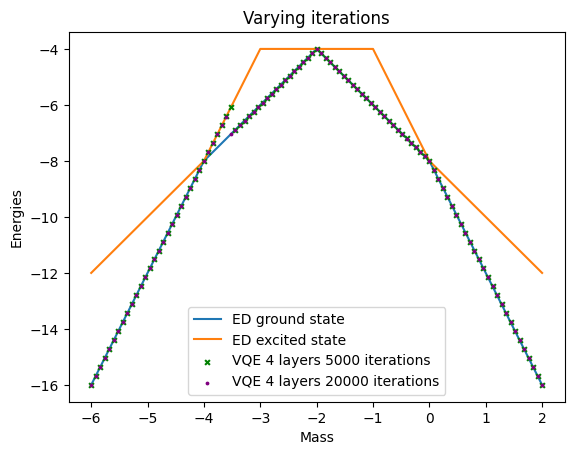

In [9]:
fig, ax = plt.subplots()
ax.plot(ed_mass, ed_energy[:, 0], label="ED ground state", zorder=-1)
ax.plot(ed_mass, ed_energy[:, 1], label="ED excited state", zorder=-1)
ax.scatter(vqe_1_mass, vqe_1_energy, label="VQE 4 layers 5000 iterations", marker='x', s=12, color='green')
ax.scatter(vqe_2_mass, vqe_2_energy, label="VQE 4 layers 20000 iterations", marker='.', s=12, color='purple')
ax.set(xlabel='Mass', ylabel='Energies')
ax.set_title("Varying iterations")
ax.legend()
fig.savefig(f"{output_filename}varying_iterations.png")
fig.savefig(f"{output_filename}varying_iterations.pdf")

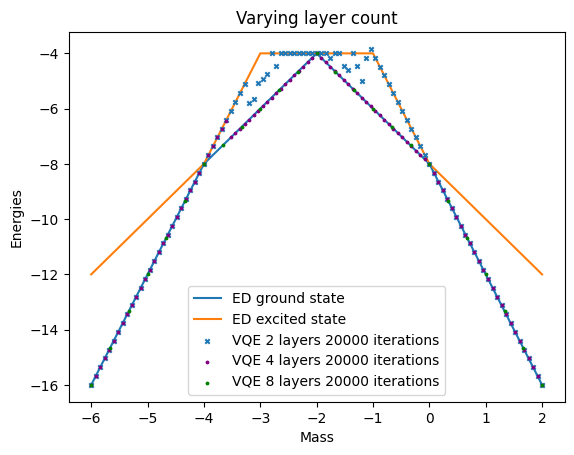

In [10]:
fig, ax = plt.subplots()
ax.plot(ed_mass, ed_energy[:, 0], label="ED ground state", zorder=-1)
ax.plot(ed_mass, ed_energy[:, 1], label="ED excited state", zorder=-1)
ax.scatter(vqe_3_mass, vqe_3_energy, label="VQE 2 layers 20000 iterations", marker='x', s=10)
ax.scatter(vqe_2_mass, vqe_2_energy, label="VQE 4 layers 20000 iterations", marker='.', color='purple', s=12)
ax.scatter(vqe_4_mass, vqe_4_energy, label="VQE 8 layers 20000 iterations", marker='.', color='green', s=12)
ax.set(xlabel='Mass', ylabel='Energies')
ax.set_title("Varying layer count")
ax.legend()
fig.savefig(f"{output_filename}varying_layer_count.png")
fig.savefig(f"{output_filename}varying_layer_count.pdf")

ParameterView([ParameterVectorElement(phi[0]), ParameterVectorElement(phi[1]), ParameterVectorElement(phi[2]), ParameterVectorElement(phi[3]), ParameterVectorElement(phi[4]), ParameterVectorElement(phi[5]), ParameterVectorElement(phi[6]), ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11]), ParameterVectorElement(θ[12]), ParameterVectorElement(θ[13]), ParameterVectorElement(θ[14]), ParameterVectorElement(θ[15]), ParameterVectorElement(θ[16]), ParameterVectorElement(θ[17]), ParameterVectorElement(θ[18]), ParameterVectorElement(θ[19]), ParameterVectorElement(θ[20]), ParameterVectorElement(θ[21]), ParameterVectorElement(θ[22])])


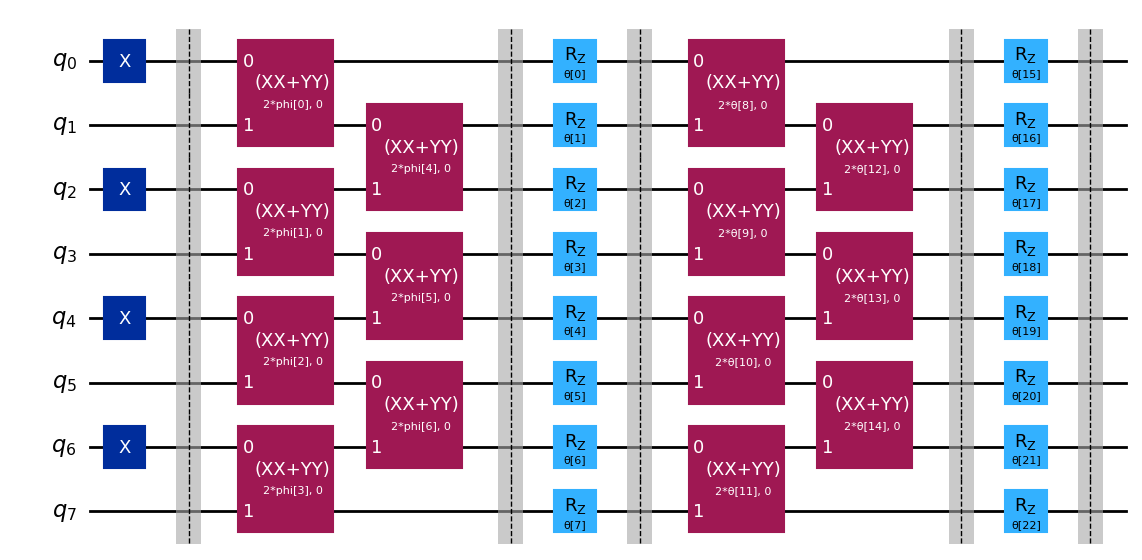

In [11]:
with h5py.File(h5_file, "r") as f:
    circuit = rebuild_ansatz(f["2025-09-03_11-10-56"])
    circuit = rebuild_ansatz(f["2025-09-03_11-11-36"])
    # circuit = rebuild_ansatz(f["2025-09-03_11-12-33"])
print(circuit.full_ansatz.parameters)
circuit.full_ansatz.draw("mpl", filename=f"{output_filename}circuit-2-layer.pdf")

ParameterView([ParameterVectorElement(phi[0]), ParameterVectorElement(phi[1]), ParameterVectorElement(phi[2]), ParameterVectorElement(phi[3]), ParameterVectorElement(phi[4]), ParameterVectorElement(phi[5]), ParameterVectorElement(phi[6]), ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11]), ParameterVectorElement(θ[12]), ParameterVectorElement(θ[13]), ParameterVectorElement(θ[14]), ParameterVectorElement(θ[15]), ParameterVectorElement(θ[16]), ParameterVectorElement(θ[17]), ParameterVectorElement(θ[18]), ParameterVectorElement(θ[19]), ParameterVectorElement(θ[20]), ParameterVectorElement(θ[21]), ParameterVectorElement(θ[22])])


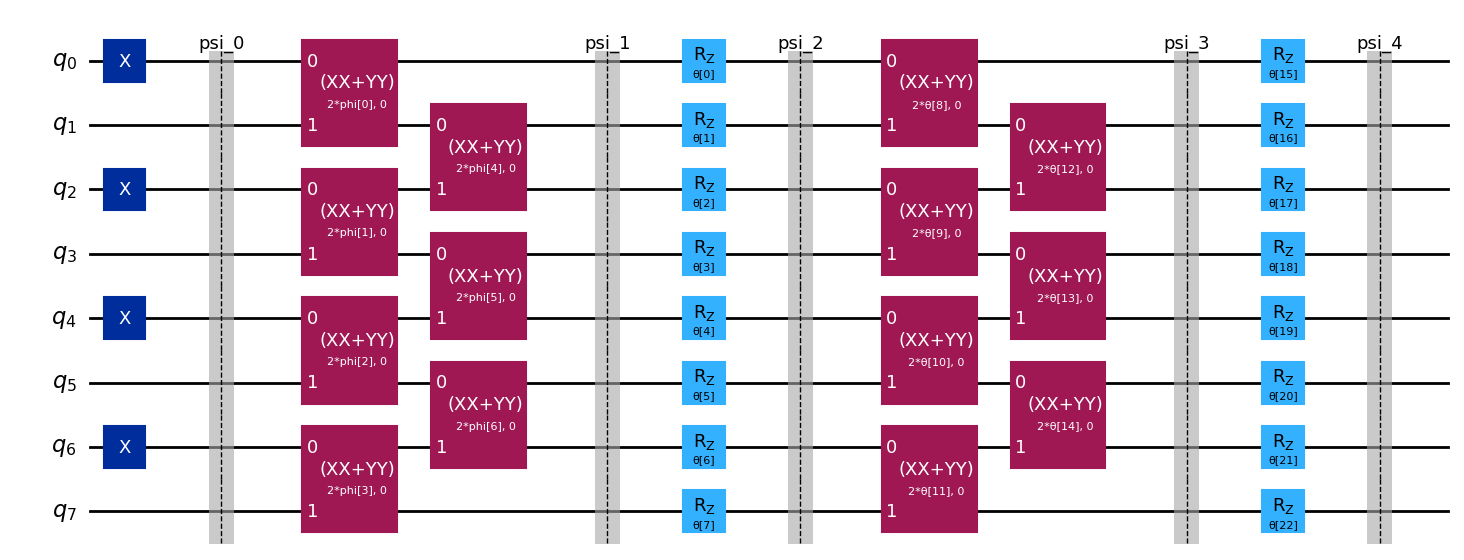

In [13]:
temp = circuit.build_full_ansatz_with_save_points()[0]
print(temp.parameters)
temp.draw("mpl")

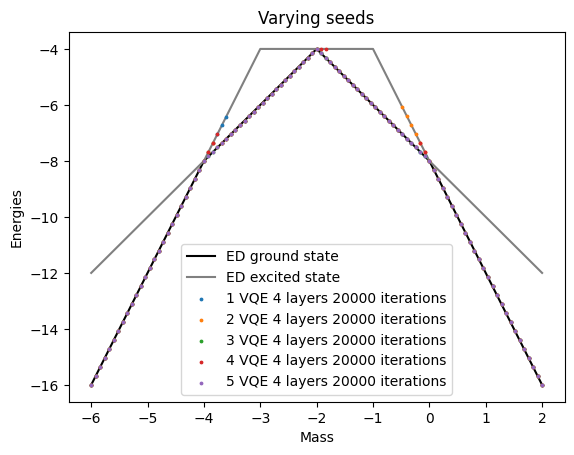

In [14]:
with h5py.File(h5_file, "r") as f:
    vqe_1_loader = ResultLoader(f["2025-09-03_11-10-56"])
    vqe_1_energy, vqe_1_mass = vqe_1_loader.get_energy_mass({})
    vqe_2_loader = ResultLoader(f["2025-09-06_15-50-13"])
    vqe_2_energy, vqe_2_mass = vqe_2_loader.get_energy_mass({})
    vqe_3_loader = ResultLoader(f["2025-09-06_15-50-13-23147802"])
    vqe_3_energy, vqe_3_mass = vqe_3_loader.get_energy_mass({})
    vqe_4_loader = ResultLoader(f["2025-09-06_15-50-13-23147804"])
    vqe_4_energy, vqe_4_mass = vqe_4_loader.get_energy_mass({})
    vqe_5_loader = ResultLoader(f["2025-09-06_15-50-13-23147805"])
    vqe_5_energy, vqe_5_mass = vqe_5_loader.get_energy_mass({})
fig, ax = plt.subplots()
ax.plot(ed_mass, ed_energy[:, 0], label="ED ground state", zorder=-1, color="black")
ax.plot(ed_mass, ed_energy[:, 1], label="ED excited state", zorder=-1, color="gray")
ax.scatter(vqe_1_mass, vqe_1_energy, label="1 VQE 4 layers 20000 iterations", marker='.', s=12)
ax.scatter(vqe_2_mass, vqe_2_energy, label="2 VQE 4 layers 20000 iterations", marker='.', s=12)
ax.scatter(vqe_3_mass, vqe_3_energy, label="3 VQE 4 layers 20000 iterations", marker='.', s=12)
ax.scatter(vqe_4_mass, vqe_4_energy, label="4 VQE 4 layers 20000 iterations", marker='.', s=12)
ax.scatter(vqe_5_mass, vqe_5_energy, label="5 VQE 4 layers 20000 iterations", marker='.', s=12)
ax.set(xlabel='Mass', ylabel='Energies')
ax.set_title("Varying seeds")
ax.legend()
fig.savefig(f"{output_filename}varying_seeds.png")
fig.savefig(f"{output_filename}varying_seeds.pdf")

In [15]:
def count_differences(labels: list[str]):
    base_label = "10101010"
    diffs = []
    for label in labels:
        if label:
            temp = 0
            for posit, letter in enumerate(label):
                if letter == base_label[posit]:
                    pass
                else:
                    temp += 1
            diffs.append(temp)
    return diffs


plt.rcParams['figure.constrained_layout.use'] = True
with h5py.File(h5_file, "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    for pos in range(0, 1000, 100):
        print(f"Mass = {ed_mass[pos]:.2f}:")
        gs_fig, gs_labels = ed_loader.plot_ground_state({HamiltonianParameters.Mass: pos})
        gs_diffs = count_differences(gs_labels)
        print("GS", np.sum(gs_diffs), gs_diffs)
        gs_fig.savefig(f"{output_filename}gs_m_{ed_mass[pos]:.2f}.png")
        plt.close(gs_fig)

        es_fig, es_labels = ed_loader.plot_excited_state({HamiltonianParameters.Mass: pos})
        es_diffs = count_differences(es_labels)
        print("ES", np.sum(es_diffs), es_diffs)
        es_fig.savefig(f"{output_filename}es_m_{ed_mass[pos]:.2f}.png")
        plt.close(es_fig)

Mass = -6.00:
(-4.5, 0.0)
(4.5, 0.0)
(25.5, 0.0)
(34.5, 0.0)
(-4.5, 30.0)
(4.5, 30.0)
(25.5, 30.0)
(34.5, 30.0)
GS 4 [4]
(-4.5, 0.0)
(4.5, 0.0)
(25.5, 0.0)
(34.5, 0.0)
(-4.5, 30.0)
(4.5, 30.0)
(25.5, 30.0)
(34.5, 30.0)
ES 64 [4, 4, 6, 6, 4, 4, 6, 2, 2, 2, 2, 4, 4, 6, 4, 4]
Mass = -5.20:
(-4.5, 0.0)
(4.5, 0.0)
(25.5, 0.0)
(34.5, 0.0)
(-4.5, 30.0)
(4.5, 30.0)
(25.5, 30.0)
(34.5, 30.0)
GS 4 [4]
(-4.5, 0.0)
(4.5, 0.0)
(25.5, 0.0)
(34.5, 0.0)
(-4.5, 30.0)
(4.5, 30.0)
(25.5, 30.0)
(34.5, 30.0)
ES 64 [4, 4, 6, 6, 4, 4, 6, 2, 2, 2, 2, 4, 4, 6, 4, 4]
Mass = -4.40:
(-4.5, 0.0)
(4.5, 0.0)
(25.5, 0.0)
(34.5, 0.0)
(-4.5, 30.0)
(4.5, 30.0)
(25.5, 30.0)
(34.5, 30.0)
GS 4 [4]
(-4.5, 0.0)
(4.5, 0.0)
(25.5, 0.0)
(34.5, 0.0)
(-4.5, 30.0)
(4.5, 30.0)
(25.5, 30.0)
(34.5, 30.0)
ES 64 [4, 4, 6, 6, 4, 4, 6, 2, 2, 2, 2, 4, 4, 6, 4, 4]
Mass = -3.60:
(-4.5, 0.0)
(4.5, 0.0)
(25.5, 0.0)
(34.5, 0.0)
(-4.5, 30.0)
(4.5, 30.0)
(25.5, 30.0)
(34.5, 30.0)
GS 64 [4, 4, 6, 6, 4, 4, 6, 2, 2, 2, 2, 4, 4, 6, 4, 4]
(-4.5, 0.0)

In [11]:
with h5py.File(h5_file, "r") as f:
    for pos in range(10, 100, 10):
        ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
        sel = {HamiltonianParameters.Mass: pos * 10}
        print(ed_loader.get_parameter_values_from_indices(sel))
        ref_state = ed_loader.get_ground_state(sel)

        vqe_5_loader = ResultLoader(f["2025-09-06_15-50-13-23147805"])
        sel = {HamiltonianParameters.Mass: pos}
        sel_values = vqe_5_loader.get_parameter_values_from_indices(sel)
        print(sel_values)

        overlaps = vqe_5_loader.save_overlap_evolution(sel, ref_state, output_filename, 1)

{<HamiltonianParameters.Mass: 'mass'>: np.float64(-5.2)}
{<HamiltonianParameters.Mass: 'mass'>: np.float64(-5.2)}
_mass_-5.20


KeyboardInterrupt: 

In [4]:
h5_file = f"{data_folder}{"2025-10-42"}.hdf5"
h5_file

'results/data/2025-10-42.hdf5'

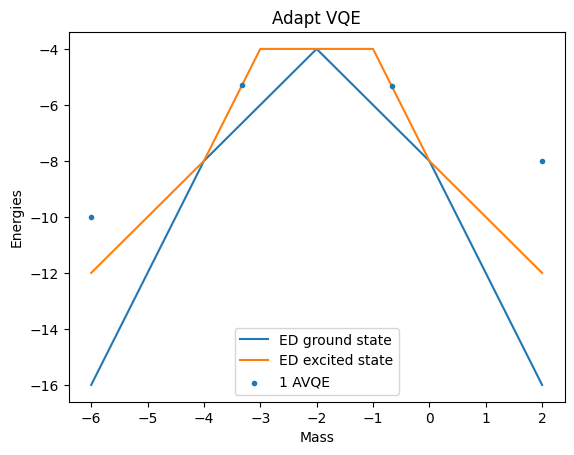

In [5]:
with h5py.File(h5_file, "r") as f:
    avqe_1_loader = ResultLoader(f["2025-10-22_17-30-26-23753983"])
    avqe_1_energy, avqe_1_mass = avqe_1_loader.get_energy_mass({})
    circuit = avqe_1_loader.get_circuit({HamiltonianParameters.Mass: 2})
fig, ax = plt.subplots()
with h5py.File(f"{data_folder}{"2025-09-35"}.hdf5", "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    ed_energy, ed_mass = ed_loader.get_energy_mass({})
ax.plot(ed_mass, ed_energy[:, 0], label="ED ground state", zorder=-1)
ax.plot(ed_mass, ed_energy[:, 1], label="ED excited state", zorder=-1)
ax.scatter(avqe_1_mass, avqe_1_energy, label="1 AVQE", marker='.')
ax.set(xlabel='Mass', ylabel='Energies')
ax.set_title("Adapt VQE")
ax.legend()
plt.show()

['mass=-0.667']


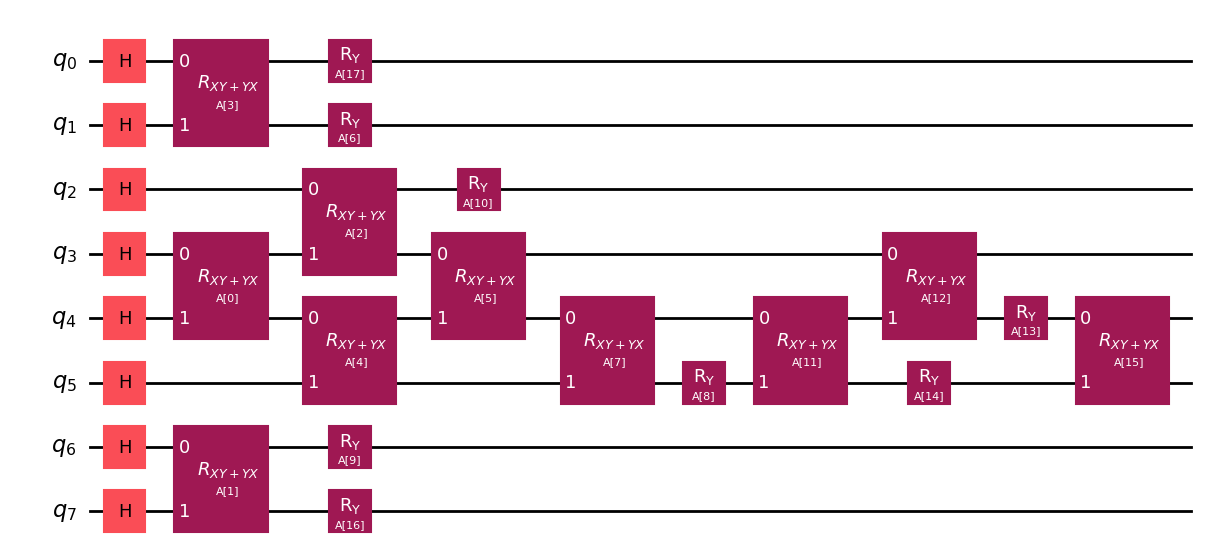

In [6]:
with h5py.File(h5_file, "r") as f:
    avqe_temp_loader = ResultLoader(f["2025-10-22_17-30-26-23753983"])

    params = {HamiltonianParameters.Mass: 2}
    circuit = avqe_temp_loader.get_circuit(params)
    print([f"{x}={y:.3f}" for x, y in avqe_temp_loader.get_parameter_values_from_indices(params).items()])
circuit.draw("mpl")

['mass=-6.000']


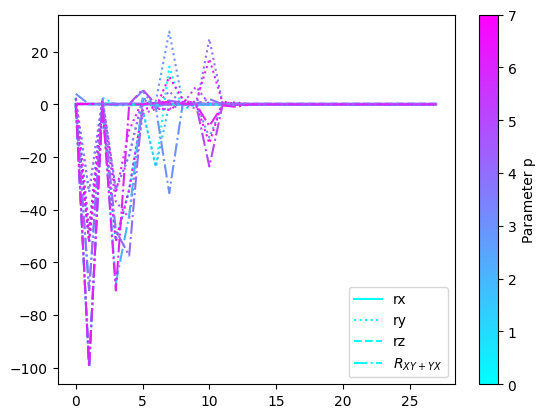

In [11]:
with h5py.File(h5_file, "r") as f:
    avqe_1_loader = ResultLoader(f["2025-10-22_17-30-26-23753983"])
    params = {HamiltonianParameters.Mass: 0}
    param_values = avqe_1_loader.get_parameter_values_from_indices(params)
    print([f"{x}={y:.3f}" for x, y in param_values.items()])

    ansatz = avqe_temp_loader.get_ansatz(params)
    ansatz: BaseADAPTVQEAnsatz

    der, _, der_dep_dict = avqe_1_loader.get_observables(VQEParameters.AnsatzOperatorDerivatives, params, [])
    sec_der, _, sec_der_dep_dict = avqe_1_loader.get_observables(VQEParameters.AnsatzOperatorSecondDerivatives, params,
                                                                 [])
    op, _, op_dep_dict = avqe_1_loader.get_observables(VQEParameters.AnsatzOperators, params, [])

    temp = avqe_1_loader.get_observables(VQEParameters.AnsatzOperatorDerivatives, params, [])[0]
fig, ax = plt.subplots()
# iterate over different operators in the pool
n_qbits = ansatz.num_qubits
param = np.arange(n_qbits)
# Colormap setup
cmap = plt.get_cmap("cool")
norm = plt.Normalize(vmin=param.min(), vmax=param.max())

linestyle_str = ['solid', 'dotted', 'dashed', 'dashdot']
already_labeled = []

for i in range(der.shape[der_dep_dict[VQEParameters.AnsatzPoolOperatorAxis]]):
    gi, qbit, gname = ansatz.get_operator_info(i)
    if gi in already_labeled:
        label = None
    else:
        label = gname
        already_labeled.append(gi)
    ax.plot(der.take(i, der_dep_dict[VQEParameters.AnsatzPoolOperatorAxis]), label=label,
                 color=cmap(norm(qbit)), linestyle = linestyle_str[gi])
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label("Parameter p")
ax.legend()
plt.show()